In [ ]:
# convert .json to pd.dataframe
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# custom functions
from common.functions import create_stocks_dataframe
from dir import stocks_historical_data
from common.prepare_data import prepare_stock_data
from common.yearwise_price_change_summary import get_historical_prices
from common.return_calculate import calculate_returns
from common.price_status import calculate_price_status

In [2]:
json_data = stocks_historical_data  # path to json file

In [3]:
# Load JSON data from file
with open(json_data, 'r') as f:
    json_data_loaded = json.load(f)

# Create the DataFrames
price_df = create_stocks_dataframe(json_data_loaded)

# For demonstration, let's create a sample with more data
# (since only 3 months of data were provided)
print("Sample of the main DataFrame:")
print(price_df.head())

Sample of the main DataFrame:
    stock_name     symbol       date  year  month  closing_price
0  A-1 Limited  542012.BO 2018-10-01  2018     10          52.67
1  A-1 Limited  542012.BO 2018-11-01  2018     11          53.01
2  A-1 Limited  542012.BO 2018-12-01  2018     12          52.50
3  A-1 Limited  542012.BO 2019-01-01  2019      1          51.39
4  A-1 Limited  542012.BO 2019-02-01  2019      2          51.26


In [4]:
# how many unique stocks are there?
unique_stocks = price_df['stock_name'].nunique()
print(f"Number of unique stocks: {unique_stocks}")

Number of unique stocks: 353


# Individual stock analysis example

In [64]:
# Individual stock analysis example
stock_name = "Affle 3i Limited"
stock_data = price_df[price_df['stock_name'] == stock_name].copy()
stock_metadata = {
    'stock_name': stock_name
}

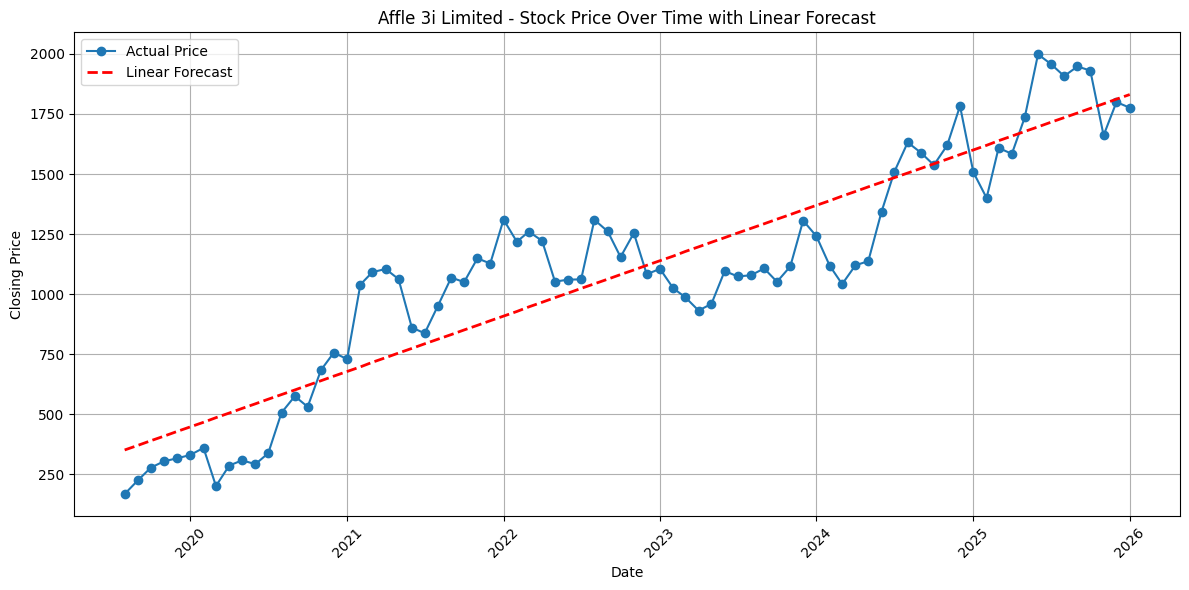

In [65]:
# Convert dates to numeric values for linear regression
x = np.arange(len(stock_data))
y = stock_data['closing_price'].values

# Fit a linear regression line
coefficients = np.polyfit(x, y, 1)
linear_fit = np.poly1d(coefficients)
forecast_line = linear_fit(x)

# Plot the closing price over time with forecast line
plt.figure(figsize=(12, 6))
plt.plot(stock_data['date'], stock_data['closing_price'], marker='o', label='Actual Price')
plt.plot(stock_data['date'], forecast_line, color='red', linestyle='--', linewidth=2, label='Linear Forecast')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title(f'{stock_name} - Stock Price Over Time with Linear Forecast')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Determine forecast direction
get_direction = "up" if coefficients[0] > 0 else "down"
print(f"The forecasted trend for {stock_name} is: {get_direction}")

The forecasted trend for ABB India Limited is: up


In [42]:
current_price = stock_data['closing_price'].iloc[-1]
forecasted_price = forecast_line[-1]

In [43]:
print(current_price, forecasted_price)

5219.0 5655.759172176308


In [ ]:

get_trend = calculate_price_status(current_price, forecasted_price, discount_threshold=1.1, precision=2)

In [67]:
# get_trend = "premium" if current_price > forecasted_price and current_price < 1.1 * forecasted_price else "at par" if current_price == forecasted_price else "discount"
# print(f"The current price is at a {get_trend} compared to the forecasted price.")

In [68]:
# # Filter data for Krishna Institute of Medical Sciences Limited
# result_df = price_df[price_df['stock_name'] == stock_name].copy()

# # Ensure date column is datetime type
# result_df['date'] = pd.to_datetime(result_df['date'])

# # Sort by date to ensure chronological order
# result_df = result_df.sort_values('date')

# # Create a DataFrame with date as index for easier lookup
# price_series = result_df.set_index('date')['closing_price']

# # Get today's date and the earliest date in your dataset
# today = datetime.now()
# earliest_date = result_df['date'].min()
# latest_date = result_df['date'].max()
# latest_price = result_df.iloc[-1]['closing_price']  # Get the latest price

# # Calculate how many years of data we have
# years_of_data = today.year - earliest_date.year

# # Create lists to store results - starting with latest date
# years_back_list = ['Latest']  # Start with 'Latest' for current price
# lookup_dates = [latest_date]
# closing_prices = [latest_price]
# target_dates_list = [today]
# days_differences = [0]


In [69]:
data_dict = prepare_stock_data(
    price_df=price_df,
    stock_name=stock_name,
    date_col='date',
    price_col='closing_price',
    name_col='stock_name')

In [70]:
# # Get prices for each year back until we run out of data
# for years_back in range(1, data_dict['years_of_data'] + 2):  # +2 to include partial years
#     # Calculate the target date (years back from today)
#     target_date = data_dict['today'] - timedelta(days=365 * years_back)
    
#     # Check if target date is before earliest date in dataset
#     if target_date < data_dict['earliest_date']:
#         print(f"\nStopping at {years_back-1} years back. Target date {target_date.date()} is before earliest data ({data_dict['earliest_date'].date()})")
#         break
    
#     # Find the closest available date and price
#     actual_date, price, days_diff = find_closest_date(target_date, data_dict['price_series'])
    
#     if actual_date is not None and price is not None:
#         data_dict['years_back_list'].append(years_back)
#         data_dict['target_dates_list'].append(target_date)
#         data_dict['lookup_dates'].append(actual_date)
#         data_dict['closing_prices'].append(price)
#         data_dict['days_differences'].append(days_diff)
#     else:
#         print(f"No data found for {years_back} years back ({target_date.date()})")

# # Create the result DataFrame
# if data_dict['years_back_list']:  # Check if we found any data
#     result_df = pd.DataFrame({
#         'Years Back': data_dict['years_back_list'],
#         'Target Date': data_dict['target_dates_list'],
#         'Actual Date': data_dict['lookup_dates'],
#         'Closing Price': data_dict['closing_prices'],
#         'Days Difference': data_dict['days_differences']
#     })
    
#     # Create simplified version with just Years Back, Actual Date, and Closing Price
#     simplified_df = result_df[['Years Back', 'Actual Date', 'Closing Price']].rename(
#         columns={'Actual Date': 'lookup_date', 'Closing Price': 'Closing price'}
#     )
    
    # print(f"\nLatest available data point: {data_dict['latest_date'].date()} - ₹{data_dict['latest_price']}")

In [71]:
# Call the function
result_df, simplified_df = get_historical_prices(data_dict)

if result_df is not None:
    print(f"Found {len(result_df)} years of historical prices")
    print(simplified_df.head())


Stopping at 6 years back. Target date 2019-01-07 is before earliest data (2019-08-01)
Found 7 years of historical prices
  Years Back lookup_date  Closing price
0     Latest  2026-01-01        1776.00
1          1  2025-01-01        1507.95
2          2  2024-01-01        1241.00
3          3  2023-01-01        1105.20
4          4  2022-01-01        1310.35


In [72]:
print(simplified_df)

  Years Back lookup_date  Closing price
0     Latest  2026-01-01        1776.00
1          1  2025-01-01        1507.95
2          2  2024-01-01        1241.00
3          3  2023-01-01        1105.20
4          4  2022-01-01        1310.35
5          5  2021-01-01         729.20
6          6  2020-01-01         330.33


In [73]:
# Calculate the returns
simplified_df = calculate_returns(simplified_df)

In [74]:
print(simplified_df)

  Years Back lookup_date  Closing price ROI(in pct)
0     Latest  2026-01-01        1776.00          18
1          1  2025-01-01        1507.95          22
2          2  2024-01-01        1241.00          12
3          3  2023-01-01        1105.20         -16
4          4  2022-01-01        1310.35          80
5          5  2021-01-01         729.20         121
6          6  2020-01-01         330.33           -


In [75]:
# Convert ROI(in pct) strings like '26%' or '-' to numeric floats (percent)
roi_numeric = pd.to_numeric(
	simplified_df['ROI(in pct)'].astype(str).str.rstrip('%').replace({'-': np.nan, '': np.nan})
)
median_return = np.nanmedian(roi_numeric)
print(f"\nMedian Return (in pct): {median_return}")
                           


Median Return (in pct): 20.0


In [76]:
# Add a new key-value pair
stock_metadata['median_return'] = float(median_return)
stock_metadata['current_return'] = float(simplified_df[simplified_df['Years Back']=='Latest']['ROI(in pct)'].values[0])
stock_metadata['direction'] = get_direction
stock_metadata['trend'] = get_trend

In [77]:
stock_metadata

{'stock_name': 'Affle 3i Limited',
 'median_return': 20.0,
 'current_return': 18.0,
 'direction': 'up',
 'trend': 'discount'}